<a href="https://colab.research.google.com/github/BRakesha/ipl-data-analysis-python/blob/main/mat_visualizationipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
ipl_real=pd.read_csv('/content/ipl_cleaned1.csv')

In [ ]:
matches_seson

,count
season,
2013,76
2022,74
2012,74
2023,74
2011,73
2024,71
2019,60
2016,60
2010,60


## Matches Per Season

##

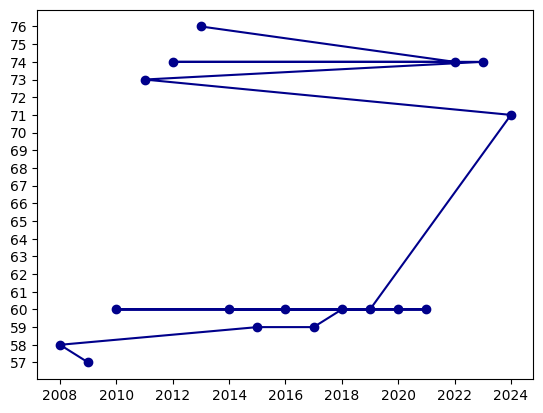

In [ ]:
matches_seson=ipl_real.season.value_counts()
plt.plot(matches_seson.index,matches_seson.values,color='darkblue',marker='o')
plt.yticks(np.arange(matches_seson.values.min(),matches_seson.values.max()+1))
# plt.gca().set_facecolor('')
plt.show()

## Avg result margin per season

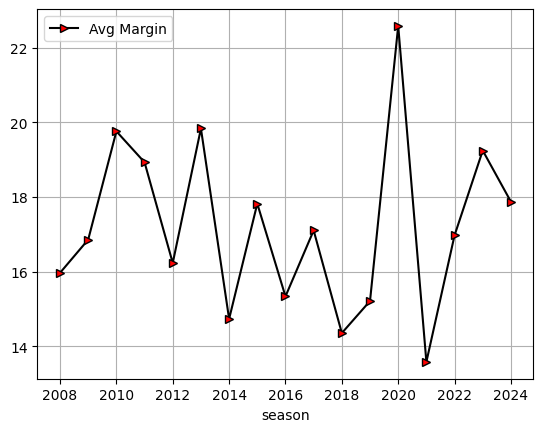

In [ ]:
avg_margin=ipl_real.groupby('season')['result_margin'].mean()
avg_margin.plot(color='black',marker='>',markerfacecolor='red',label='Avg Margin')
plt.legend()
plt.grid()
plt.show()

## per season how many matches went to super over

<Axes: xlabel='season'>

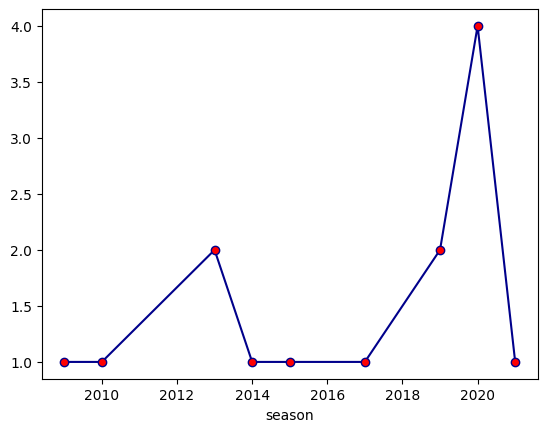

In [ ]:
super_overs=ipl_real[ipl_real['super_over']==True]
season_wise=super_overs.groupby('season').size()
season_wise.plot(color='darkblue',marker='o',markerfacecolor='red')

## Batting Vs Fieldind Decision

Text(0.5, 1.0, 'Bat Vs Field Decision')

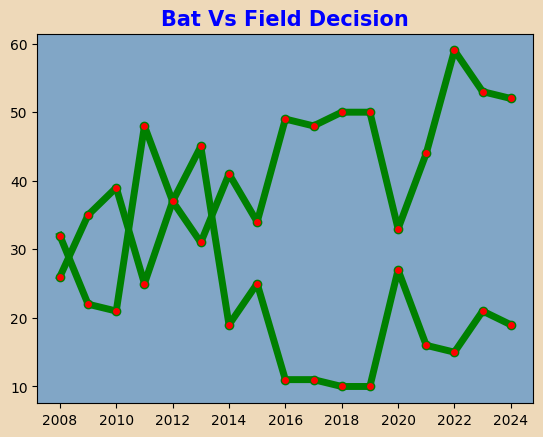

In [ ]:
bat_decison=ipl_real[ipl_real['toss_decision']=='bat'].groupby('season').size()
bowl_decision=ipl_real[ipl_real['toss_decision']=='field'].groupby('season').size()



decison_yearwise=pd.concat((bat_decison,bowl_decision),axis=1)


decison_yearwise.columns=['bat','bowl']

plt.gca().set_facecolor('#81A6C6')
plt.gcf().set_facecolor('#EED9B9')
plt.plot(decison_yearwise,color='green',marker='o',markerfacecolor='red',linewidth='5')
plt.title('Bat Vs Field Decision',color='blue',fontsize=15,fontweight='bold')

## RCB Season wise Wins

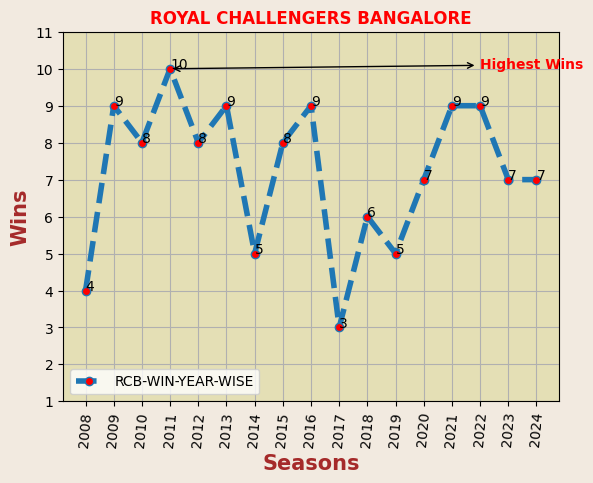

In [ ]:
rcb=ipl_real[ipl_real['winner']=='Royal Challengers Bengaluru']

# annotate() is used to add text labels (notes) on a graph at a specific point.

rcb_seasonwise=rcb.groupby('season')['winner'].size()

plt.plot(rcb_seasonwise,
         marker='o',markerfacecolor='red',
         ls='dashed',
         lw=4,
         label='RCB-WIN-YEAR-WISE')
plt.xlabel("Seasons",fontsize=15,color='brown',fontweight='bold')
plt.ylabel("Wins",fontsize=15,color='brown',fontweight='bold')
plt.title('ROYAL CHALLENGERS BANGALORE',color='red',fontweight='bold')
plt.legend(loc="lower left")
plt.xticks(rcb_seasonwise.index,rotation=85)
plt.yticks(np.arange(1,12))
plt.grid(True)

plt.gca().set_facecolor('#E4DFB5')
plt.gcf().set_facecolor('#F2EAE0')


for i,j in zip(rcb_seasonwise.index,rcb_seasonwise.values):
  plt.annotate(j,(i,j))




plt.annotate('Highest Wins',(2011,10),xytext=(2022,10),color='red',fontweight='bold',arrowprops={'arrowstyle':'<->'})

plt.show()

## csk seasonwise wins

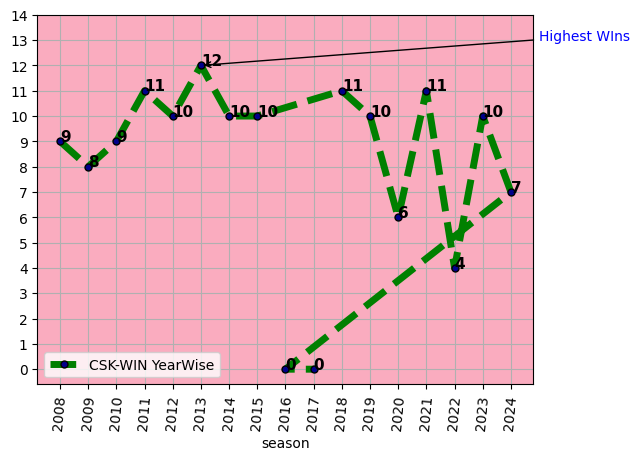

In [ ]:
csk=ipl_real[ipl_real['winner']=='Chennai Super Kings']


csk_winseaonwise=csk.groupby('season')['winner'].size()

csk_winseaonwise[2016]=0
csk_winseaonwise[2017]=0




csk_winseaonwise.plot(color='green',
                      marker='o',linewidth=5,
                      markerfacecolor='darkblue',
                      markeredgecolor='black',
                      markersize=5,
                      linestyle='dashed',
                      label='CSK-WIN YearWise')


for i,j in zip(csk_winseaonwise.index,csk_winseaonwise.values):
  plt.annotate((j),(i,j),fontsize=11,fontweight='bold')



plt.xticks(np.arange(2008,2025),rotation=85)
plt.yticks(np.arange(0,15))


plt.annotate('Highest WIns',(csk_winseaonwise.idxmax(),csk_winseaonwise.max()),xytext=(2025,13),arrowprops={'arrowstyle':'->'},color='blue')

plt.gca().set_facecolor('#FAACBF') # It returns the current plotting area (axes) of the graph.
# plt.gcf().set_facecolor('red')

plt.legend()
plt.grid()
plt.show()
# we have call show fn after all operation done
# to show specified label on chart we have to use legend()

MI VS **CSK**

In [ ]:
mi=ipl_real[ipl_real['winner']=='Mumbai Indians']
mi_seasonwise=mi.groupby('season')['winner'].size()


In [ ]:
mivscsk=pd.concat((mi_seasonwise,csk_winseaonwise),axis=1)
mivscsk.columns=['MI WINS','CSK WINs']
mivscsk['CSK WINs']=mivscsk['CSK WINs'].fillna(0)
comparision=mivscsk.apply(lambda row:row['MI WINS'] if row['MI WINS']>row['CSK WINs'] else row['CSK WINs'],axis=1)

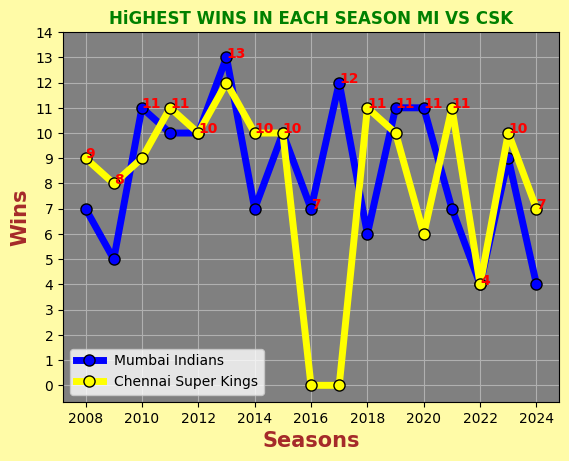

In [ ]:
mivscsk.plot(label='MI VS CSK',color=('blue','yellow'),lw=5,marker='o',markersize=8,markeredgecolor='black')
plt.xlabel("Seasons",fontsize=15,color='brown',fontweight='bold')
plt.ylabel("Wins",fontsize=15,color='brown',fontweight='bold')

plt.legend(['Mumbai Indians','Chennai Super Kings'])

plt.gca().set_facecolor('gray')
plt.gcf().set_facecolor('#FFFBA7')

plt.title('HiGHEST WINS IN EACH SEASON MI VS CSK',color='green',fontweight='bold')

for i,j in zip(comparision.index,comparision.values):
  plt.annotate(int(j),(i,j),color='red',fontweight='bold')

plt.yticks(np.arange(0,15))
plt.grid(True)
plt.show()



TEAM VS TEAM

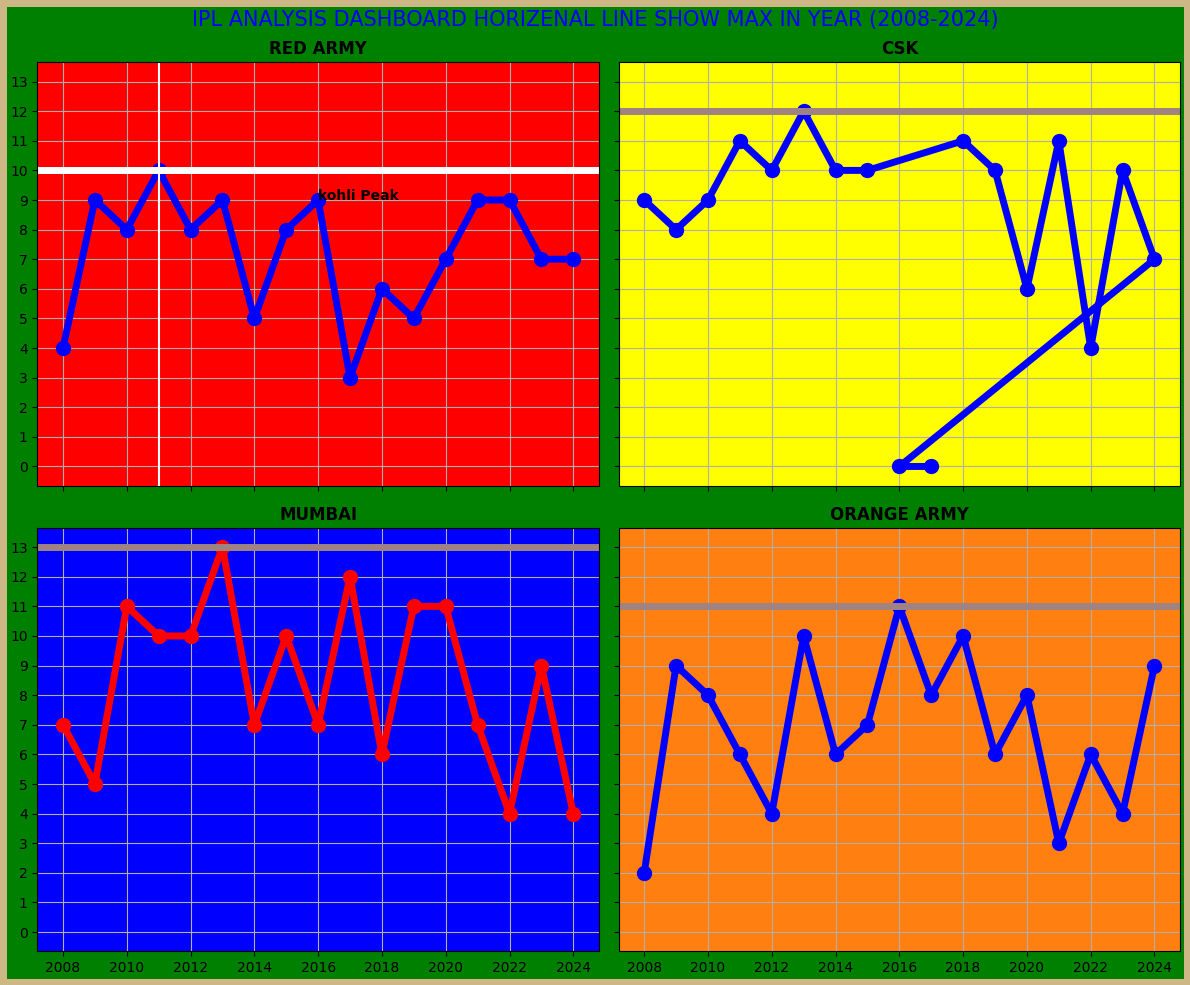

In [ ]:

fig , axis=plt.subplots(2,2,sharex=True,sharey=True,figsize=(12,10),edgecolor='#CDB885',linewidth=8)

# plt.figure(figsize=(10,10))

# axis  = all the sub plots stored in axis var in the form of list 2d

orange_wise=ipl_real[ipl_real['winner']=='Sunrisers Hyderabad'].groupby('season')['winner'].count()

fig.set_facecolor('green')

# fig.suptitle('WINS FOR TEAMS YEAR WISE ',fontsize=20,color='white')
fig.suptitle(
    "IPL Analysis Dashboard horizenal line show max in year (2008-2024)".upper(),
    fontsize=15,
    color='blue'
)
# fig.text(0.3, 0.2, "Data Source: IPL",fontsize=50,rotation=45)

axis[0][0].plot(rcb_seasonwise.index,rcb_seasonwise.values,color='blue',lw=5,marker='o',markersize=10)
axis[0][0].set_xticks(list(range(rcb_seasonwise.index.min(),rcb_seasonwise.index.max()+1,2)))

axis[0][0].tick_params(axis='x',rotation=90)
axis[0][0].set_yticks(np.arange(0,15))
# axis[0][0].set_xlabel('Years')
axis[0][0].set_facecolor('red')

axis[0][0].text(2016,9,"kohli Peak",fontweight='bold')

axis[0][1].plot(csk_winseaonwise,color='blue',lw=5,marker='o',markersize=10)
axis[0][1].set_facecolor('yellow')


axis[1][0].plot(mi_seasonwise,color='red',lw=5,marker='o',markersize=10)
axis[1][0].set_facecolor('blue')


axis[1][1].plot(orange_wise,color='blue',lw=5,marker='o',markersize=10)
axis[1][1].set_facecolor('#FF7F11')


for ax in axis:
  for i in range(0,2):
    ax[i].grid()
    line=ax[i].lines[0]
    ax[i].axhline(y=line.get_ydata().max(),lw=5,color='#9F8383')

titles=iter(['RED ARMY','CSK','MUMBAI','ORANGE ARMY'])
for ax in axis:
  for i in range(0,2):
    ax[i].set_title(next(titles),fontsize=12,fontweight='bold')



fig.savefig('dash.jpg')

axis[0][0].axhline(y=rcb_seasonwise.max(),color='white',lw=5)
axis[0][0].axvline(x=rcb_seasonwise.idxmax(),color='white')


fig.tight_layout()
fig.show()